# ST1504 CA2 Part B: Pendulum Control Using Reinforcement Learning

## Objective

The objective of this project is to build and evaluate a Deep Q-Network (DQN) agent capable of balancing a pendulum by applying appropriate torque.

The Pendulum environment provides the agent with three observations:

- Cosine of the pendulum angle
- Sine of the pendulum angle
- Angular velocity of the pendulum

Since the original action space is continuous, the available torque values will be discretised so that DQN can be applied.

The performance of the DQN agent will be investigated under four gravity conditions:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

In this project, the DQN agent will be trained, evaluated and systematically improved to determine a suitable setup for balancing the pendulum under the different gravity conditions.

In [1]:
import gym
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from collections import deque
from tensorflow.keras import layers

print("Gym version:", gym.__version__)
print("TensorFlow version:", tf.__version__)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Gym version: 0.25.2
TensorFlow version: 2.10.0


## Environment Setup

Unlike supervised learning tasks, reinforcement learning does not begin with a fixed dataset. Instead, training data is generated through interactions between the agent and its environment.

The OpenAI Gym Pendulum environment is created as the data source for this project. During each interaction, the environment provides the agent with a state. The agent selects an action, receives a reward and observes the resulting next state.

The default gravity setting will first be used to explore the environment and develop the baseline DQN agent.

In [2]:
env = gym.make("Pendulum-v1")

state = env.reset()

print("Environment:", env)
print("Initial state:", state)
print("State shape:", state.shape)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Default gravity:", env.unwrapped.g)

env.close()

Environment: <TimeLimit<OrderEnforcing<StepAPICompatibility<PassiveEnvChecker<PendulumEnv<Pendulum-v1>>>>>>
Initial state: [ 0.53054065 -0.84765947 -0.45641243]
State shape: (3,)
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Default gravity: 10.0


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


# Exploratory Data Analysis (EDA)
### Environment Structure

The Pendulum environment represents each state using three numerical observations:

- The cosine of the pendulum angle
- The sine of the pendulum angle
- The angular velocity of the pendulum

The first two observations range from **-1 to 1**, while angular velocity ranges from **-8 to 8**. Each state therefore has a shape of **(3,)**.

The original action consists of one continuous torque value ranging from **-2 to 2**. Since DQN requires discrete actions, this action space will later be discretised during preprocessing.

Each episode has a maximum duration of **200 time steps**.

In [3]:
env = gym.make("Pendulum-v1")

print("Observation shape:", env.observation_space.shape)
print("Observation minimum values:", env.observation_space.low)
print("Observation maximum values:", env.observation_space.high)

print("Action shape:", env.action_space.shape)
print("Action minimum value:", env.action_space.low)
print("Action maximum value:", env.action_space.high)

print("Maximum episode length:", env.spec.max_episode_steps)
print("Gravity:", env.unwrapped.g)

env.close()

Observation shape: (3,)
Observation minimum values: [-1. -1. -8.]
Observation maximum values: [1. 1. 8.]
Action shape: (1,)
Action minimum value: [-2.]
Action maximum value: [2.]
Maximum episode length: 200
Gravity: 10.0


### Collection of Random-Agent Interaction Data

Unlike a traditional dataset, reinforcement learning data is generated when an agent interacts with the environment.

A random agent was used to complete multiple episodes. At each time step, the following information was recorded:

- Current state
- Selected torque
- Reward received
- Total episodic return

This exploratory data will be used to examine the distributions of the observations, actions and rewards before developing the DQN agent.

In [4]:
env = gym.make("Pendulum-v1")
state = env.reset(seed=42)

number_of_episodes = 50

collected_states = []
collected_actions = []
collected_rewards = []
episode_returns = []

for episode in range(number_of_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()

        next_state, reward, done, info = env.step(action)

        collected_states.append(state)
        collected_actions.append(action[0])
        collected_rewards.append(reward)

        total_reward += reward
        state = next_state

    episode_returns.append(total_reward)

env.close()

collected_states = np.array(collected_states)
collected_actions = np.array(collected_actions)
collected_rewards = np.array(collected_rewards)
episode_returns = np.array(episode_returns)

print("Collected states:", collected_states.shape)
print("Collected actions:", collected_actions.shape)
print("Collected rewards:", collected_rewards.shape)
print("Episode returns:", episode_returns.shape)

Collected states: (10000, 3)
Collected actions: (10000,)
Collected rewards: (10000,)
Episode returns: (50,)


### Interaction Data Quality

The randomly collected states, actions and rewards were checked for missing and infinite values.

Reinforcement learning environments normally generate valid numerical observations. However, this check is still important because invalid values could cause unstable gradients or prevent the DQN from training correctly.

If no missing or infinite values are found, all collected interactions can be retained for exploratory analysis.

In [5]:
print(
    "Missing state values:",
    np.isnan(collected_states).sum()
)

print(
    "Infinite state values:",
    np.isinf(collected_states).sum()
)

print(
    "Missing action values:",
    np.isnan(collected_actions).sum()
)

print(
    "Infinite action values:",
    np.isinf(collected_actions).sum()
)

print(
    "Missing reward values:",
    np.isnan(collected_rewards).sum()
)

print(
    "Infinite reward values:",
    np.isinf(collected_rewards).sum()
)

Missing state values: 0
Infinite state values: 0
Missing action values: 0
Infinite action values: 0
Missing reward values: 0
Infinite reward values: 0


### Distribution of State Observations

The distributions of the three state observations were examined using histograms.

The cosine and sine observations describe the pendulum’s angular position, while angular velocity describes the speed and direction of its rotation.

This analysis helps identify the ranges and distributions experienced by a random agent. It also indicates whether state normalisation may be useful before DQN training.

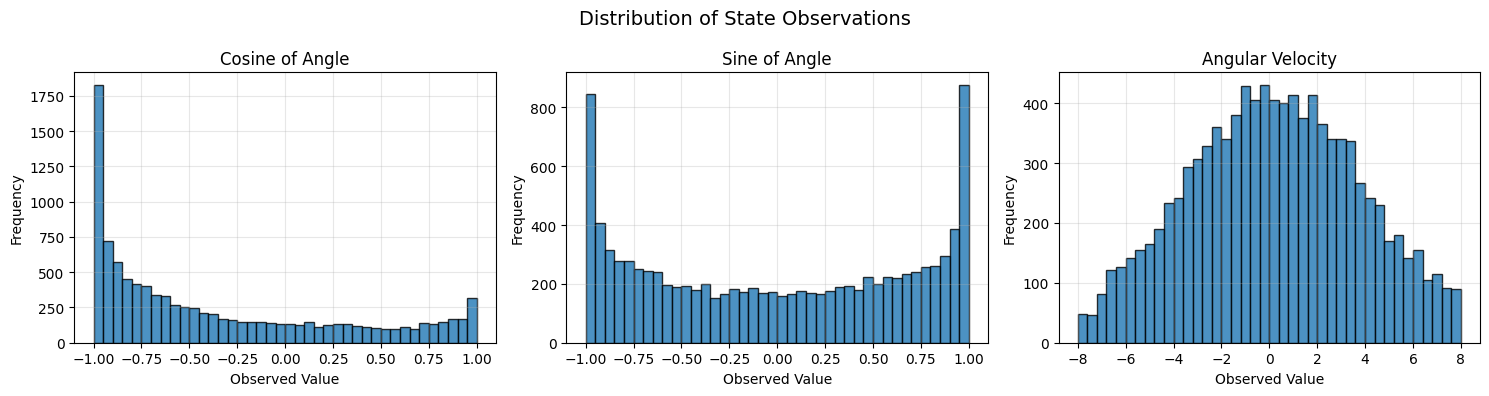

In [6]:
state_names = [
    "Cosine of Angle",
    "Sine of Angle",
    "Angular Velocity"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for index, axis in enumerate(axes):
    axis.hist(
        collected_states[:, index],
        bins=40,
        alpha=0.8,
        edgecolor="black"
    )

    axis.set_title(state_names[index])
    axis.set_xlabel("Observed Value")
    axis.set_ylabel("Frequency")
    axis.grid(alpha=0.3)

plt.suptitle(
    "Distribution of State Observations",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Interpretation of State Distributions

The cosine observation is strongly concentrated near **-1**. Since a cosine value of -1 represents the pendulum pointing downwards, this shows that the random agent frequently allows the pendulum to remain near its natural hanging position. In comparison, the desired upright position has a cosine value near **1**.

The sine observation covers the complete range from -1 to 1, showing that the pendulum moves through positions on both sides of its rotation.

Angular velocity is approximately centred around zero and ranges from about -8 to 8. Its numerical range is considerably wider than the cosine and sine observations, which are limited to -1 to 1. Therefore, scaling angular velocity may help ensure that it does not have a disproportionately large influence during DQN training.

### Distribution of Random Actions and Rewards

The distributions of the randomly selected torque values and the resulting rewards were examined.

Since the actions were sampled randomly from the continuous action space, torque values across the range of -2 to 2 are expected. The reward distribution provides a baseline indication of the performance achieved without learning.

For the Pendulum environment, rewards are negative. Values closer to zero represent better control of the pendulum.

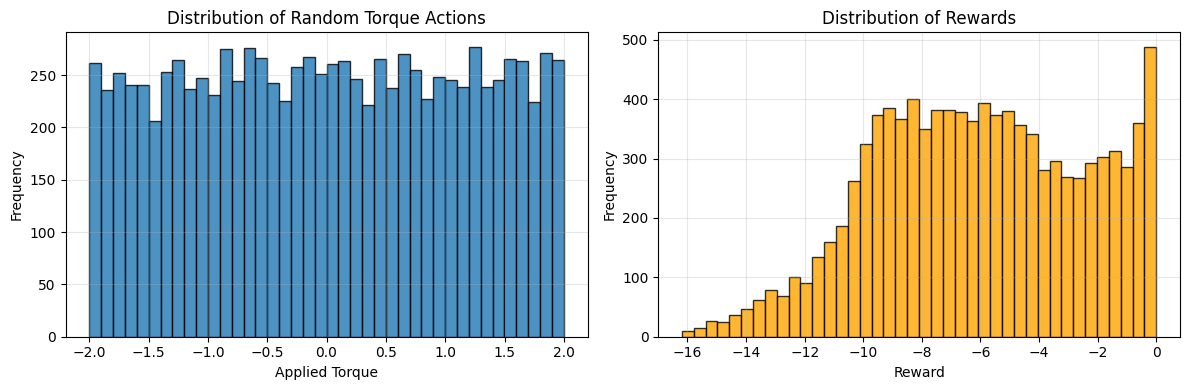

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    collected_actions,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribution of Random Torque Actions")
axes[0].set_xlabel("Applied Torque")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].hist(
    collected_rewards,
    bins=40,
    edgecolor="black",
    alpha=0.8,
    color="orange"
)

axes[1].set_title("Distribution of Rewards")
axes[1].set_xlabel("Reward")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Random Actions and Rewards

The random torque actions are distributed approximately evenly across the complete range from **-2 to 2**. This confirms that the random agent does not favour any particular torque value or direction.

The per-step rewards range from approximately **-16 to 0**, with most rewards occurring around -10 to -4. Since the maximum possible reward is zero, the mainly negative distribution indicates that the random agent generally fails to keep the pendulum upright and stable.

A smaller number of rewards appear close to zero, showing that the pendulum occasionally reaches a favourable position by chance. However, the random agent cannot maintain this position consistently because it does not learn from previous interactions.

These results provide a baseline that the trained DQN agent should improve upon by achieving rewards that are more consistently concentrated closer to zero.

### Initial Comparison of Gravity Conditions

The Pendulum environment was explored under the four gravity conditions required by the assignment:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

A random agent was evaluated under each condition to examine how gravity affects the environment before DQN training.

The same number of episodes and random seed were used for every gravity condition to make the comparison fair. These results represent untrained baseline performance and will later be compared with the trained DQN agents.

In [8]:
gravity_settings = {
    "Default": 10.0,
    "Free-fall": 0.0,
    "Anti-gravity": -10.0,
    "Supergravity": 15.0
}

episodes_per_gravity = 30
gravity_baseline_returns = {}

for gravity_name, gravity_value in gravity_settings.items():
    env = gym.make("Pendulum-v1")
    env.unwrapped.g = gravity_value

    env.seed(42)
    env.action_space.seed(42)

    condition_returns = []

    for episode in range(episodes_per_gravity):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

        condition_returns.append(total_reward)

    gravity_baseline_returns[gravity_name] = np.array(
        condition_returns
    )

    env.close()

    print(
        gravity_name,
        "- Mean:",
        np.mean(condition_returns),
        "- Standard deviation:",
        np.std(condition_returns)
    )

c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


Default - Mean: -1189.63307601102 - Standard deviation: 231.64725307533595
Free-fall - Mean: -748.6178031504127 - Standard deviation: 184.61422238394752
Anti-gravity - Mean: -602.1183430727535 - Standard deviation: 396.9365950877032
Supergravity - Mean: -1386.837203404409 - Standard deviation: 124.56566538166022


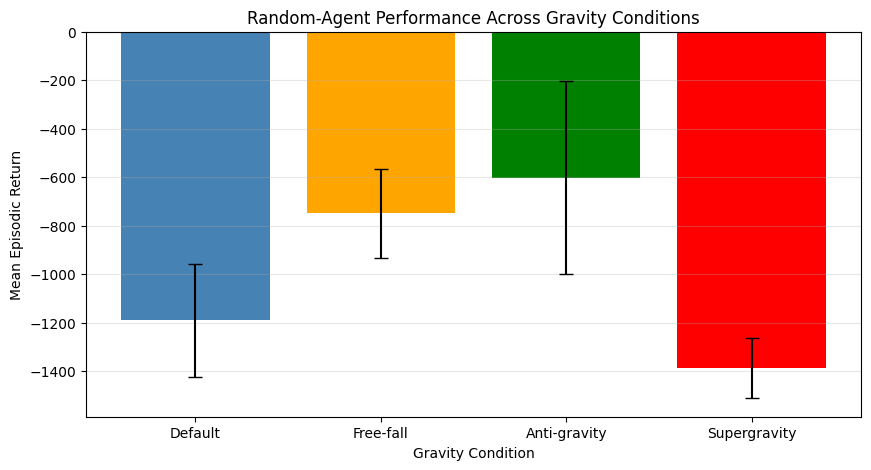

In [9]:
gravity_names = list(gravity_baseline_returns.keys())

mean_returns = [
    gravity_baseline_returns[name].mean()
    for name in gravity_names
]

return_standard_deviations = [
    gravity_baseline_returns[name].std()
    for name in gravity_names
]

plt.figure(figsize=(10, 5))

plt.bar(
    gravity_names,
    mean_returns,
    yerr=return_standard_deviations,
    capsize=5,
    color=["steelblue", "orange", "green", "red"]
)

plt.title("Random-Agent Performance Across Gravity Conditions")
plt.xlabel("Gravity Condition")
plt.ylabel("Mean Episodic Return")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation of Gravity Baselines

The random agent achieved different levels of performance under the four gravity conditions.

Free-fall produced the highest mean episodic return, with an average of approximately **-760**. Without gravitational force pulling the pendulum downwards, the random agent was more likely to remain in comparatively favourable positions.

Anti-gravity produced the second-highest mean return of approximately **-850**. However, it also had the largest standard deviation, indicating that its performance varied considerably between episodes.

The default-gravity condition produced a lower mean return of approximately **-1350**, while supergravity produced the lowest mean return of approximately **-1480**. The stronger gravitational force in supergravity makes it more difficult for randomly selected torque actions to move and maintain the pendulum near the upright position.

The overlapping error bars show that random-agent performance varies between episodes. Therefore, multiple evaluation episodes should also be used when comparing trained DQN agents.

Each trained agent should be compared against the random baseline from the same gravity condition because the four environments have different levels of difficulty.

In [10]:
# EDA: Verify Custom Gravity Testing Compatibility
gravity_test_values = [10.0, 0.0, -10.0, 15.0]

print("Testing dynamic gravity configuration:")
for g in gravity_test_values:
    test_env = gym.make("Pendulum-v1")
    test_env.unwrapped.g = g
    test_env.reset()
    
    # Execute 1 dummy step
    _, reward, _, _ = test_env.step(test_env.action_space.sample())
    print(f"  Gravity set to {g:5.1f} | Sample Step Reward: {reward:.4f}")
    test_env.close()

Testing dynamic gravity configuration:
  Gravity set to  10.0 | Sample Step Reward: -6.2645
  Gravity set to   0.0 | Sample Step Reward: -2.1024
  Gravity set to -10.0 | Sample Step Reward: -7.9064
  Gravity set to  15.0 | Sample Step Reward: -3.1029


## Data Preprocessing

The exploratory analysis found no missing or infinite values in the environment observations, actions or rewards. Therefore, no interaction data needs to be removed or imputed.

However, two preprocessing steps are required before DQN can be applied:

1. Discretise the continuous torque action space.
2. Scale the state observations to a similar numerical range.

These transformations will make the Pendulum environment suitable for training with a Deep Q-Network.

# Observation Normalization Function

In [11]:
import numpy as np

# Preprocessing: State Observation Scaler
def normalize_state(state):
    """
    Normalize Pendulum state to approximately [-1, 1].

    State format:
        state[0] = cos(theta)  -> already in [-1, 1]
        state[1] = sin(theta)  -> already in [-1, 1]
        state[2] = theta_dot   -> expected in [-8, 8]

    Returns:
        Normalized state as float32.
    """
    state = np.asarray(state, dtype=np.float32).copy()

    # Scale angular velocity
    state[2] = np.clip(state[2] / 8.0, -1.0, 1.0)

    return state

sample_raw_state = np.array([0.5, -0.5, 6.0], dtype=np.float32)
sample_norm_state = normalize_state(sample_raw_state)

print("Raw State Sample        :", sample_raw_state)
print("Normalized State Sample :", sample_norm_state)

Raw State Sample        : [ 0.5 -0.5  6. ]
Normalized State Sample : [ 0.5  -0.5   0.75]


### Action-Space Discretisation

The original Pendulum action space contains continuous torque values ranging from -2 to 2. However, DQN can only select from a fixed number of discrete actions.

For the baseline model, the continuous range is divided into five evenly spaced torque values:

- Strong clockwise torque
- Weak clockwise torque
- No torque
- Weak counter-clockwise torque
- Strong counter-clockwise torque

Five actions provide a simple baseline while still allowing the agent to control both the direction and strength of the applied torque. Different numbers of actions can later be investigated as a systematic improvement.

In [12]:
# Action Space Discretization & Mapping Setup
import numpy as np

# Number of discrete output actions for the Deep Q-Network
number_of_actions = 5

# Dynamically fetch continuous torque bounds from the gym environment
low_torque = float(env.action_space.low[0])
high_torque = float(env.action_space.high[0])

# Generate evenly spaced discrete torque values [-2.0, -1.0, 0.0, 1.0, 2.0]
torque_values = np.linspace(
    low_torque, 
    high_torque, 
    number_of_actions,
    dtype=np.float32
)

def get_action_torque(action_index):
    """
    Maps a discrete action index (0 to 4) to the 1D NumPy array 
    format required by Gym's env.step().
    
    Handles Python ints, NumPy integers, and PyTorch tensor scalars seamlessly.
    """
    # Convert scalar tensors/numpy ints to standard Python integer
    idx = int(action_index)
    
    # Boundary check for model safety
    if idx < 0 or idx >= number_of_actions:
        raise ValueError(
            f"Action index {idx} is out of bounds! "
            f"Must be between 0 and {number_of_actions - 1}."
        )
        
    return np.array([torque_values[idx]], dtype=np.float32)


# --- Verification Tests ---
print("Discrete Action Mapping Verification:")
for action_idx in range(number_of_actions):
    continuous_torque = get_action_torque(action_idx)
    print(
        f"  Discrete Index {action_idx} ---> "
        f"Array: {continuous_torque} | "
        f"Shape: {continuous_torque.shape} | "
        f"Type: {continuous_torque.dtype}"
    )

Discrete Action Mapping Verification:
  Discrete Index 0 ---> Array: [-2.] | Shape: (1,) | Type: float32
  Discrete Index 1 ---> Array: [-1.] | Shape: (1,) | Type: float32
  Discrete Index 2 ---> Array: [0.] | Shape: (1,) | Type: float32
  Discrete Index 3 ---> Array: [1.] | Shape: (1,) | Type: float32
  Discrete Index 4 ---> Array: [2.] | Shape: (1,) | Type: float32


In [13]:
def action_index_to_torque(action_index):
    torque = torque_values[action_index]

    return np.array(
        [torque],
        dtype=np.float32
    )

In [14]:
test_action_index = 3
test_torque = action_index_to_torque(
    test_action_index
)

print("Selected action index:", test_action_index)
print("Applied torque:", test_torque)

Selected action index: 3
Applied torque: [1.]


### State Casting and Scaling

The state contains three observations with different numerical ranges:

- Cosine of angle: -1 to 1
- Sine of angle: -1 to 1
- Angular velocity: -8 to 8

The cosine and sine observations are already within the range of -1 to 1. However, angular velocity has a much wider range and could have a disproportionately large influence on the neural network.

Therefore, angular velocity is divided by 8 so that all three state features are approximately within the same range of -1 to 1.

The states are also converted to `float32`, which is suitable for TensorFlow model training.

In [15]:
state_scale = np.array(
    [1.0, 1.0, 8.0],
    dtype=np.float32
)


def preprocess_state(state):
    state = np.asarray(
        state,
        dtype=np.float32
    )

    scaled_state = state / state_scale

    return np.clip(
        scaled_state,
        -1.0,
        1.0
    )

In [16]:
env = gym.make("Pendulum-v1")

original_state = env.reset()
processed_state = preprocess_state(
    original_state
)

env.close()

print("Original state:", original_state)
print("Processed state:", processed_state)

print(
    "Processed datatype:",
    processed_state.dtype
)

Original state: [-0.5999561  0.8000329  0.6565969]
Processed state: [-0.5999561   0.8000329   0.08207461]
Processed datatype: float32


In [17]:
processed_collected_states = np.array([
    preprocess_state(state)
    for state in collected_states
])

print(
    "Original minimum values:",
    collected_states.min(axis=0)
)

print(
    "Original maximum values:",
    collected_states.max(axis=0)
)

print(
    "Processed minimum values:",
    processed_collected_states.min(axis=0)
)

print(
    "Processed maximum values:",
    processed_collected_states.max(axis=0)
)

Original minimum values: [-0.99999994 -0.99999994 -8.        ]
Original maximum values: [0.9999987 1.        8.       ]
Processed minimum values: [-0.99999994 -0.99999994 -1.        ]
Processed maximum values: [0.9999987 1.        1.       ]


### Verification of State Preprocessing

Before preprocessing, the cosine and sine observations were already within the range of -1 to 1, while angular velocity ranged from -8 to 8.

After scaling, all three observations were within approximately -1 to 1. This confirms that angular velocity was successfully scaled without changing the original meaning of the state.

Small differences from the exact limits, such as 0.9999997 instead of 1.0, are caused by floating-point precision and do not require correction.

## Modelling

Two DQN designs are investigated for each assigned gravity:

1. **Baseline DQN** — standard replay buffer, target network, epsilon-greedy exploration and mean squared error loss.
2. **Improved DQN** — Double DQN, dueling architecture, Prioritized Experience Replay and Huber loss.

The continuous torque range is discretised because DQN requires a finite action space. Separate agents and weight files are produced for Default and Supergravity because the environment dynamics change with gravity.


### Model Configurations

The baseline uses five actions and a smaller network to establish a simple reference. The Improved DQN uses fifteen torque actions for finer control and a lower learning rate for more gradual updates. Configuration dictionaries are kept separate for each gravity so that individual parameters can be adjusted later if controlled tuning shows that different settings are required.


In [18]:
BASELINE_CONFIGS = {
    "Default": {
        "gravity": 10.0,
        "num_actions": 5,
        "learning_rate": 0.001,
        "gamma": 0.99,
        "epsilon_start": 1.0,
        "epsilon_decay": 0.98,
        "epsilon_min": 0.01,
        "batch_size": 64,
        "memory_size": 20000,
        "target_update_frequency": 5,
        "num_episodes": 150
    },
    "Supergravity": {
        "gravity": 15.0,
        "num_actions": 5,
        "learning_rate": 0.001,
        "gamma": 0.99,
        "epsilon_start": 1.0,
        "epsilon_decay": 0.98,
        "epsilon_min": 0.01,
        "batch_size": 64,
        "memory_size": 20000,
        "target_update_frequency": 5,
        "num_episodes": 150
    }
}

IMPROVED_CONFIGS = {
    "Default": {
        **BASELINE_CONFIGS["Default"],
        "num_actions": 15,
        "learning_rate": 0.0005,
        "per_alpha": 0.6,
        "per_beta_start": 0.4,
        "per_beta_increment": 0.00005
    },
    "Supergravity": {
        **BASELINE_CONFIGS["Supergravity"],
        "num_actions": 15,
        "learning_rate": 0.0005,
        "per_alpha": 0.6,
        "per_beta_start": 0.4,
        "per_beta_increment": 0.00005
    }
}

print("Baseline configurations")
for gravity_name, config in BASELINE_CONFIGS.items():
    print(gravity_name, config)

print("\nImproved configurations")
for gravity_name, config in IMPROVED_CONFIGS.items():
    print(gravity_name, config)


Baseline configurations
Default {'gravity': 10.0, 'num_actions': 5, 'learning_rate': 0.001, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_decay': 0.98, 'epsilon_min': 0.01, 'batch_size': 64, 'memory_size': 20000, 'target_update_frequency': 5, 'num_episodes': 150}
Supergravity {'gravity': 15.0, 'num_actions': 5, 'learning_rate': 0.001, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_decay': 0.98, 'epsilon_min': 0.01, 'batch_size': 64, 'memory_size': 20000, 'target_update_frequency': 5, 'num_episodes': 150}

Improved configurations
Default {'gravity': 10.0, 'num_actions': 15, 'learning_rate': 0.0005, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_decay': 0.98, 'epsilon_min': 0.01, 'batch_size': 64, 'memory_size': 20000, 'target_update_frequency': 5, 'num_episodes': 150, 'per_alpha': 0.6, 'per_beta_start': 0.4, 'per_beta_increment': 5e-05}
Supergravity {'gravity': 15.0, 'num_actions': 15, 'learning_rate': 0.0005, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_decay': 0.98, 'epsilon_min': 0.01

### Environment and Training-Graph Helpers

The environment helpers support both the older four-value and newer five-value Gym step formats. Every observation is preprocessed before it enters the neural network. The plotting helper displays raw episode values faintly together with a 10-episode moving average.

In [19]:
def create_env(gravity):
    return gym.make(
        "Pendulum-v1",
        g=float(gravity)
    )


def reset_environment(env, seed=None):
    result = env.reset(seed=seed) if seed is not None else env.reset()
    state = result[0] if isinstance(result, tuple) else result
    return preprocess_state(state)


def step_environment(env, action):
    result = env.step(action)

    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated
    else:
        next_state, reward, done, info = result

    return preprocess_state(next_state), float(reward), bool(done), info


def moving_average(values, window=10):
    values = np.asarray(values, dtype=np.float32)

    if len(values) < window:
        return values

    return np.convolve(
        values,
        np.ones(window, dtype=np.float32) / window,
        mode="valid"
    )



def plot_training_history(results, metric, ylabel, title, window=10):
    if not results:
        print("Train the agents before plotting the training history.")
        return

    colours = {
        "Default": "tab:blue",
        "Supergravity": "tab:red"
    }

    plt.figure(figsize=(11, 5))

    for gravity_name, result in results.items():
        values = np.asarray(result[metric], dtype=np.float32)
        valid_mask = np.isfinite(values)
        valid_values = values[valid_mask]
        valid_episodes = np.arange(1, len(values) + 1)[valid_mask]

        plt.plot(
            valid_episodes,
            valid_values,
            color=colours[gravity_name],
            alpha=0.18
        )

        if len(valid_values) >= window:
            smoothed = moving_average(valid_values, window=window)
            smooth_episodes = valid_episodes[window - 1:]
            plt.plot(
                smooth_episodes,
                smoothed,
                color=colours[gravity_name],
                linewidth=2,
                label=f"{gravity_name} ({window}-episode average)"
            )
        else:
            plt.plot(
                valid_episodes,
                valid_values,
                color=colours[gravity_name],
                linewidth=2,
                label=gravity_name
            )

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 1. Baseline Deep Q-Network

The baseline network receives the three preprocessed state values and outputs one Q-value for each of five discrete torque actions. A replay buffer reduces correlation between consecutive transitions, while a separate target network provides more stable target values.

The baseline uses the standard DQN maximum target and mean squared error loss. Its purpose is to provide a clear reference for measuring whether the advanced components in the Improved DQN produce meaningful gains.


### 1. Baseline Deep Q-Network

The baseline DQN receives the three preprocessed state observations and produces one Q-value for each discretised torque action. It uses epsilon-greedy exploration, a replay buffer and a separate target network.

The same baseline settings are used for default gravity and supergravity so that their initial learning behaviour can be compared fairly.

In [20]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, config):
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)
        self.gamma = float(config["gamma"])
        self.learning_rate = float(config["learning_rate"])

        self.epsilon = float(config["epsilon_start"])
        self.epsilon_decay = float(config["epsilon_decay"])
        self.epsilon_min = float(config["epsilon_min"])

        self.batch_size = int(config["batch_size"])
        self.memory = deque(maxlen=int(config["memory_size"]))

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_network()

    def _build_model(self):
        model = tf.keras.Sequential([
            layers.Input(shape=(self.state_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(self.action_dim, activation="linear")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=self.learning_rate
            ),
            loss="mse"
        )
        return model

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state, explore=True):
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        state_tensor = tf.convert_to_tensor(
            state[None, :],
            dtype=tf.float32
        )
        q_values = self.model(state_tensor, training=False)
        return int(tf.argmax(q_values[0]).numpy())

    def replay(self):
        if len(self.memory) < self.batch_size:
            return None

        minibatch = random.sample(self.memory, self.batch_size)

        states = np.asarray([item[0] for item in minibatch], dtype=np.float32)
        actions = np.asarray([item[1] for item in minibatch], dtype=np.int32)
        rewards = np.asarray([item[2] for item in minibatch], dtype=np.float32)
        next_states = np.asarray([item[3] for item in minibatch], dtype=np.float32)
        dones = np.asarray([item[4] for item in minibatch], dtype=np.float32)

        training_targets = self.model(states, training=False).numpy()
        target_next_q = self.target_model(next_states, training=False).numpy()
        target_values = (
            rewards
            + (1.0 - dones) * self.gamma * np.max(target_next_q, axis=1)
        )
        training_targets[
            np.arange(self.batch_size),
            actions
        ] = target_values

        loss = self.model.train_on_batch(states, training_targets)
        return float(np.asarray(loss).reshape(-1)[0])


### Shared Training Procedure

The same training procedure is used for the baseline and Improved DQN to maintain a fair experimental structure. Episode reward, mean episode loss and epsilon are recorded. A checkpoint is saved whenever the latest 10-episode mean reward improves, and the strongest checkpoint is restored before evaluation.

In [21]:
def train_agent(
    gravity_name,
    config,
    agent_class,
    model_label,
    seed=42
):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    env = create_env(config["gravity"])
    action_values = create_action_values(config["num_actions"])

    agent = agent_class(
        state_dim=env.observation_space.shape[0],
        action_dim=config["num_actions"],
        config=config
    )

    episode_returns = []
    episode_losses = []
    epsilon_history = []
    best_moving_return = -np.inf
    checkpoint_path = (
        f"best_{model_label.lower()}_{gravity_name.lower()}.h5"
    )

    print(
        f"\nTraining {model_label} | {gravity_name} "
        f"(g={config['gravity']}, actions={config['num_actions']})"
    )

    for episode in range(1, config["num_episodes"] + 1):
        state = reset_environment(env, seed=seed + episode)
        done = False
        total_reward = 0.0
        step_losses = []

        while not done:
            action_index = agent.act(state, explore=True)
            torque = action_index_to_torque(action_index, action_values)
            next_state, reward, done, _ = step_environment(env, torque)

            agent.remember(
                state,
                action_index,
                reward,
                next_state,
                done
            )

            loss = agent.replay()
            if loss is not None:
                step_losses.append(loss)

            state = next_state
            total_reward += reward

        episode_returns.append(total_reward)
        episode_losses.append(
            np.mean(step_losses) if step_losses else np.nan
        )
        epsilon_history.append(agent.epsilon)

        agent.epsilon = max(
            agent.epsilon_min,
            agent.epsilon * agent.epsilon_decay
        )

        if episode % config["target_update_frequency"] == 0:
            agent.update_target_network()

        if len(episode_returns) >= 10:
            current_moving_return = np.mean(episode_returns[-10:])

            if current_moving_return > best_moving_return:
                best_moving_return = current_moving_return
                agent.model.save_weights(checkpoint_path)

        if episode == 1 or episode % 10 == 0:
            print(
                f"Episode {episode:3d}/{config['num_episodes']} | "
                f"Reward: {total_reward:8.2f} | "
                f"Loss: {episode_losses[-1]:8.4f} | "
                f"Epsilon: {agent.epsilon:.3f}"
            )

    env.close()

    agent.model.load_weights(checkpoint_path)
    agent.update_target_network()

    return {
        "agent": agent,
        "returns": np.asarray(episode_returns, dtype=np.float32),
        "losses": np.asarray(episode_losses, dtype=np.float32),
        "epsilon": np.asarray(epsilon_history, dtype=np.float32),
        "best_moving_return": float(best_moving_return),
        "checkpoint_path": checkpoint_path,
        "action_values": action_values,
        "config": config.copy()
    }


In [22]:
action_env = gym.make(
    "Pendulum-v1",
    new_step_api=True
)

ACTION_LOW = float(action_env.action_space.low[0])
ACTION_HIGH = float(action_env.action_space.high[0])

action_env.close()


def create_action_values(num_actions):
    return np.linspace(
        ACTION_LOW,
        ACTION_HIGH,
        int(num_actions),
        dtype=np.float32
    )


def action_index_to_torque(action_index, action_values):
    action_index = int(action_index)

    if not 0 <= action_index < len(action_values):
        raise ValueError(
            "Action index is outside the discretised action space."
        )

    return np.array(
        [action_values[action_index]],
        dtype=np.float32
    )

### Baseline Training

Two baseline agents are trained: one under Default gravity and one under Supergravity. Set `RUN_BASELINE_TRAINING` to `False` only when intentionally skipping retraining within the same active kernel session.

In [23]:
RUN_BASELINE_TRAINING = True
baseline_results = {}

if RUN_BASELINE_TRAINING:
    for gravity_name, config in BASELINE_CONFIGS.items():
        baseline_results[gravity_name] = train_agent(
            gravity_name=gravity_name,
            config=config,
            agent_class=DQNAgent,
            model_label="Baseline",
            seed=42
        )
else:
    print("Set RUN_BASELINE_TRAINING = True to train the baseline agents.")


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)



Training Baseline | Default (g=10.0, actions=5)
Episode   1/150 | Reward:  -861.78 | Loss:   2.7330 | Epsilon: 0.980
Episode  10/150 | Reward: -1287.45 | Loss:   0.0399 | Epsilon: 0.817
Episode  20/150 | Reward: -1279.65 | Loss:   0.3093 | Epsilon: 0.668
Episode  30/150 | Reward: -1305.64 | Loss:   1.1414 | Epsilon: 0.545
Episode  40/150 | Reward: -1214.41 | Loss:   1.2518 | Epsilon: 0.446
Episode  50/150 | Reward:  -773.23 | Loss:   2.3368 | Epsilon: 0.364
Episode  60/150 | Reward:  -516.90 | Loss:   2.3866 | Epsilon: 0.298
Episode  70/150 | Reward:  -260.18 | Loss:   3.8504 | Epsilon: 0.243
Episode  80/150 | Reward:  -513.66 | Loss:   4.9825 | Epsilon: 0.199
Episode  90/150 | Reward:  -378.00 | Loss:   4.2096 | Epsilon: 0.162
Episode 100/150 | Reward:  -350.22 | Loss:   3.6710 | Epsilon: 0.133
Episode 110/150 | Reward:  -123.42 | Loss:   3.8235 | Epsilon: 0.108
Episode 120/150 | Reward:  -233.04 | Loss:   4.0421 | Epsilon: 0.089
Episode 130/150 | Reward:  -250.00 | Loss:   3.1718 | 

### Baseline Reward and Loss Graphs

Higher episodic returns closer to zero indicate stronger control. The loss graph shows how the baseline network’s mean squared temporal-difference error changes during training. Reinforcement-learning loss is not expected to decrease smoothly because the replay data and learning targets continually change.

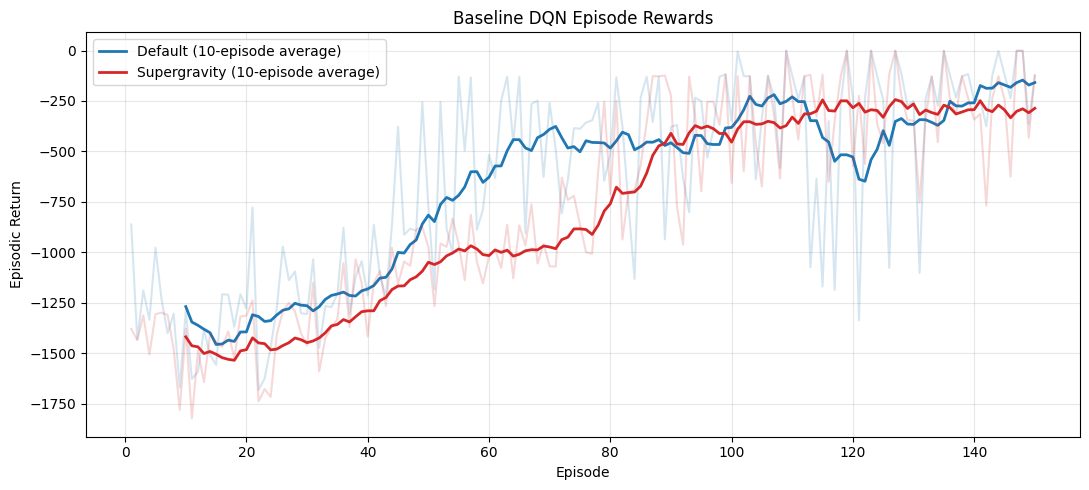

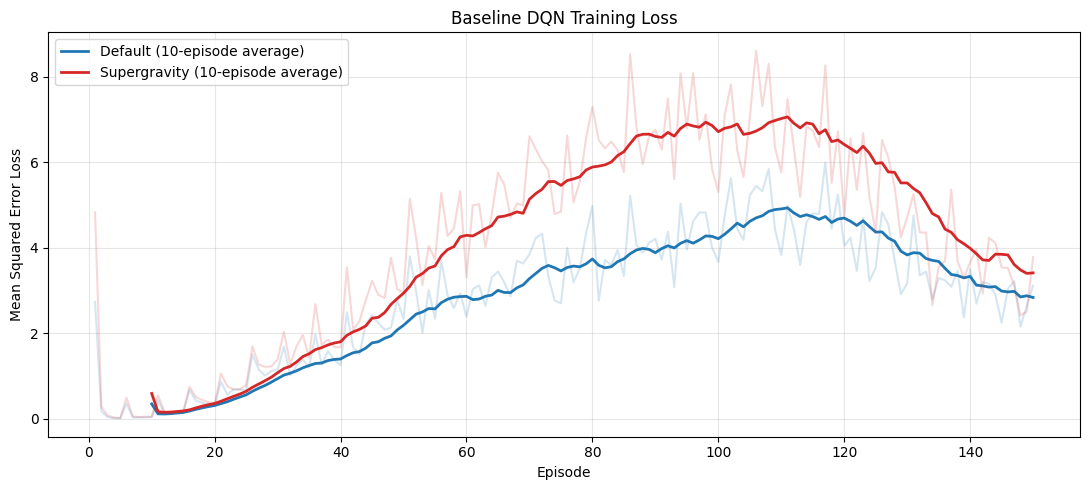

In [24]:
plot_training_history(
    baseline_results,
    metric="returns",
    ylabel="Episodic Return",
    title="Baseline DQN Episode Rewards"
)

plot_training_history(
    baseline_results,
    metric="losses",
    ylabel="Mean Squared Error Loss",
    title="Baseline DQN Training Loss"
)

## 2. Improved Deep Q-Network

The Improved DQN introduces four changes:

- **Double DQN** separates next-action selection from target evaluation to reduce Q-value overestimation.
- **Dueling architecture** estimates state value and action advantages separately.
- **Prioritized Experience Replay** samples transitions with larger temporal-difference errors more frequently.
- **Huber loss** reduces the influence of unusually large errors.

The Improved DQN uses the same training and evaluation structure as the baseline, but its advanced replay and target calculations are implemented inside the agent.


### Prioritized Experience Replay

Importance-sampling weights reduce the bias created by non-uniform replay sampling. Beta gradually increases towards 1 during training.


In [25]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = int(capacity)
        self.alpha = float(alpha)
        self.buffer = []
        self.priorities = np.zeros(self.capacity, dtype=np.float32)
        self.position = 0

    def add(self, transition):
        maximum_priority = (
            self.priorities[:len(self.buffer)].max()
            if self.buffer else 1.0
        )

        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.position] = transition

        self.priorities[self.position] = max(float(maximum_priority), 1e-5)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size, beta):
        valid_priorities = self.priorities[:len(self.buffer)]
        scaled_priorities = valid_priorities ** self.alpha
        probabilities = scaled_priorities / scaled_priorities.sum()

        indices = np.random.choice(
            len(self.buffer),
            size=batch_size,
            replace=True,
            p=probabilities
        )
        samples = [self.buffer[index] for index in indices]

        weights = (len(self.buffer) * probabilities[indices]) ** (-beta)
        weights /= weights.max()

        return samples, indices, weights.astype(np.float32)

    def update_priorities(self, indices, priorities):
        for index, priority in zip(indices, priorities):
            self.priorities[index] = max(float(priority), 1e-5)

    def __len__(self):
        return len(self.buffer)


### Dueling Double-DQN Agent

The network first extracts shared features, then separates into state-value and action-advantage streams. The replay method uses the online model to select the best next action and the target model to evaluate that action.

In [26]:
class ImprovedDQNAgent:
    def __init__(self, state_dim, action_dim, config):
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)
        self.gamma = float(config["gamma"])
        self.learning_rate = float(config["learning_rate"])

        self.epsilon = float(config["epsilon_start"])
        self.epsilon_decay = float(config["epsilon_decay"])
        self.epsilon_min = float(config["epsilon_min"])

        self.batch_size = int(config["batch_size"])
        self.memory = PrioritizedReplayBuffer(
            capacity=config["memory_size"],
            alpha=config["per_alpha"]
        )
        self.beta = float(config["per_beta_start"])
        self.beta_increment = float(config["per_beta_increment"])

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_network()

    def _build_model(self):
        inputs = layers.Input(shape=(self.state_dim,))

        features = layers.Dense(128, activation="relu")(inputs)
        features = layers.Dense(128, activation="relu")(features)

        value = layers.Dense(64, activation="relu")(features)
        value = layers.Dense(1, name="state_value")(value)

        advantage = layers.Dense(64, activation="relu")(features)
        advantage = layers.Dense(
            self.action_dim,
            name="action_advantage"
        )(advantage)

        centred_advantage = layers.Lambda(
            lambda values: values - tf.reduce_mean(
                values,
                axis=1,
                keepdims=True
            )
        )(advantage)

        q_values = layers.Lambda(
            lambda tensors: tensors[0] + tensors[1]
        )([value, centred_advantage])

        model = tf.keras.Model(inputs=inputs, outputs=q_values)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=self.learning_rate
            ),
            loss=tf.keras.losses.Huber()
        )
        return model

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.add((state, action, reward, next_state, done))

    def act(self, state, explore=True):
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        state_tensor = tf.convert_to_tensor(
            state[None, :],
            dtype=tf.float32
        )
        q_values = self.model(state_tensor, training=False)
        return int(tf.argmax(q_values[0]).numpy())

    def replay(self):
        if len(self.memory) < self.batch_size:
            return None

        minibatch, indices, weights = self.memory.sample(
            self.batch_size,
            beta=self.beta
        )

        states = np.asarray([item[0] for item in minibatch], dtype=np.float32)
        actions = np.asarray([item[1] for item in minibatch], dtype=np.int32)
        rewards = np.asarray([item[2] for item in minibatch], dtype=np.float32)
        next_states = np.asarray([item[3] for item in minibatch], dtype=np.float32)
        dones = np.asarray([item[4] for item in minibatch], dtype=np.float32)

        current_q = self.model(states, training=False).numpy()

        # Double DQN: online model selects; target model evaluates.
        online_next_q = self.model(next_states, training=False).numpy()
        best_next_actions = np.argmax(online_next_q, axis=1)
        target_next_q = self.target_model(next_states, training=False).numpy()
        selected_next_q = target_next_q[
            np.arange(self.batch_size),
            best_next_actions
        ]

        target_values = (
            rewards
            + (1.0 - dones) * self.gamma * selected_next_q
        )

        previous_values = current_q[
            np.arange(self.batch_size),
            actions
        ].copy()

        training_targets = current_q.copy()
        training_targets[
            np.arange(self.batch_size),
            actions
        ] = target_values

        td_errors = np.abs(target_values - previous_values)
        self.memory.update_priorities(indices, td_errors + 1e-5)

        loss = self.model.train_on_batch(
            states,
            training_targets,
            sample_weight=weights
        )

        self.beta = min(1.0, self.beta + self.beta_increment)

        return float(np.asarray(loss).reshape(-1)[0])


### Improved-DQN Training

Separate Improved DQN agents are trained for Default and Supergravity using the same random seed as the baseline agents.

In [27]:
RUN_IMPROVED_TRAINING = True
improved_results = {}

if RUN_IMPROVED_TRAINING:
    for gravity_name, config in IMPROVED_CONFIGS.items():
        improved_results[gravity_name] = train_agent(
            gravity_name=gravity_name,
            config=config,
            agent_class=ImprovedDQNAgent,
            model_label="Improved",
            seed=42
        )
else:
    print("Set RUN_IMPROVED_TRAINING = True to train the Improved DQN agents.")


Training Improved | Default (g=10.0, actions=15)
Episode   1/150 | Reward:  -889.38 | Loss:   0.0847 | Epsilon: 0.980
Episode  10/150 | Reward: -1174.82 | Loss:   0.0025 | Epsilon: 0.817
Episode  20/150 | Reward: -1380.73 | Loss:   0.0089 | Epsilon: 0.668
Episode  30/150 | Reward: -1267.97 | Loss:   0.0095 | Epsilon: 0.545
Episode  40/150 | Reward: -1292.14 | Loss:   0.0068 | Epsilon: 0.446
Episode  50/150 | Reward:  -867.31 | Loss:   0.0052 | Epsilon: 0.364
Episode  60/150 | Reward:  -769.01 | Loss:   0.0041 | Epsilon: 0.298
Episode  70/150 | Reward:  -519.65 | Loss:   0.0049 | Epsilon: 0.243
Episode  80/150 | Reward:  -261.15 | Loss:   0.0053 | Epsilon: 0.199
Episode  90/150 | Reward:  -358.73 | Loss:   0.0056 | Epsilon: 0.162
Episode 100/150 | Reward:  -463.82 | Loss:   0.0068 | Epsilon: 0.133
Episode 110/150 | Reward:  -120.29 | Loss:   0.0062 | Epsilon: 0.108
Episode 120/150 | Reward:  -285.40 | Loss:   0.0078 | Epsilon: 0.089
Episode 130/150 | Reward:  -256.59 | Loss:   0.0078 |

### Improved-DQN Reward and Loss Graphs

The reward graph shows whether the agent learns stronger pendulum control over time. The loss graph displays mean Huber loss per episode. The Huber and baseline MSE loss values should not be compared directly because they use different numerical definitions; each loss curve is used mainly to check its own model’s training stability.

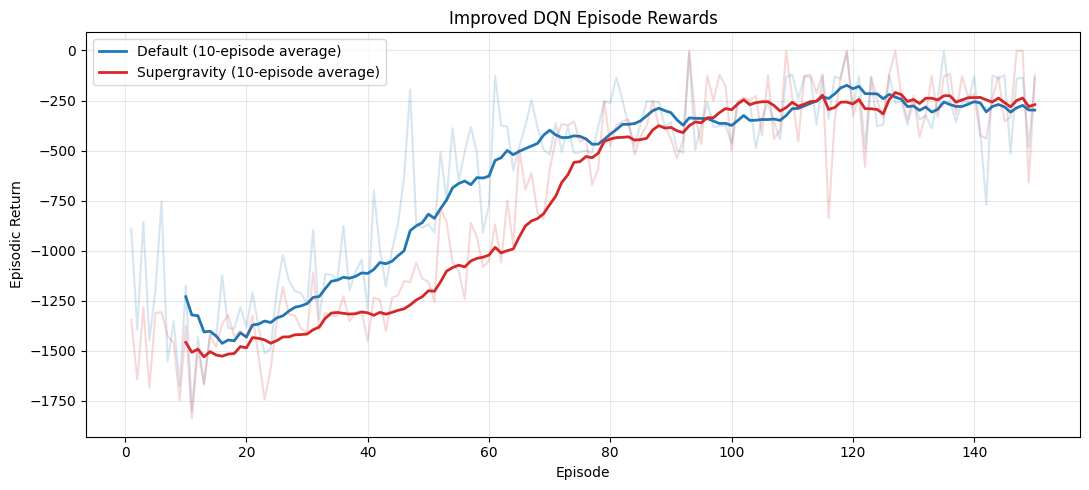

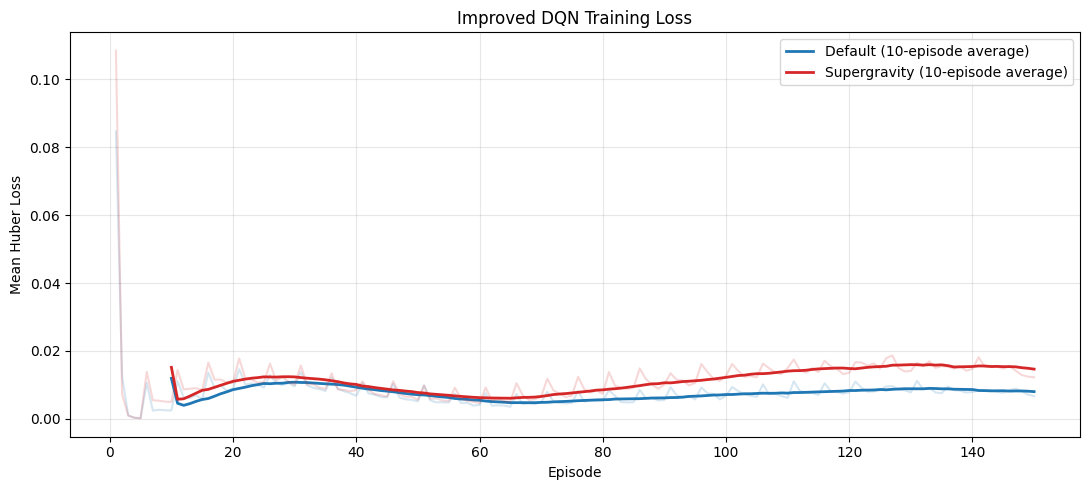

In [28]:
plot_training_history(
    improved_results,
    metric="returns",
    ylabel="Episodic Return",
    title="Improved DQN Episode Rewards"
)

plot_training_history(
    improved_results,
    metric="losses",
    ylabel="Mean Huber Loss",
    title="Improved DQN Training Loss"
)


## Baseline and Improved Learning-Curve Comparison

The following reward curves compare learning progress within each gravity condition. The comparison uses a 10-episode moving average so that overall trends are clearer than individual episode fluctuations.


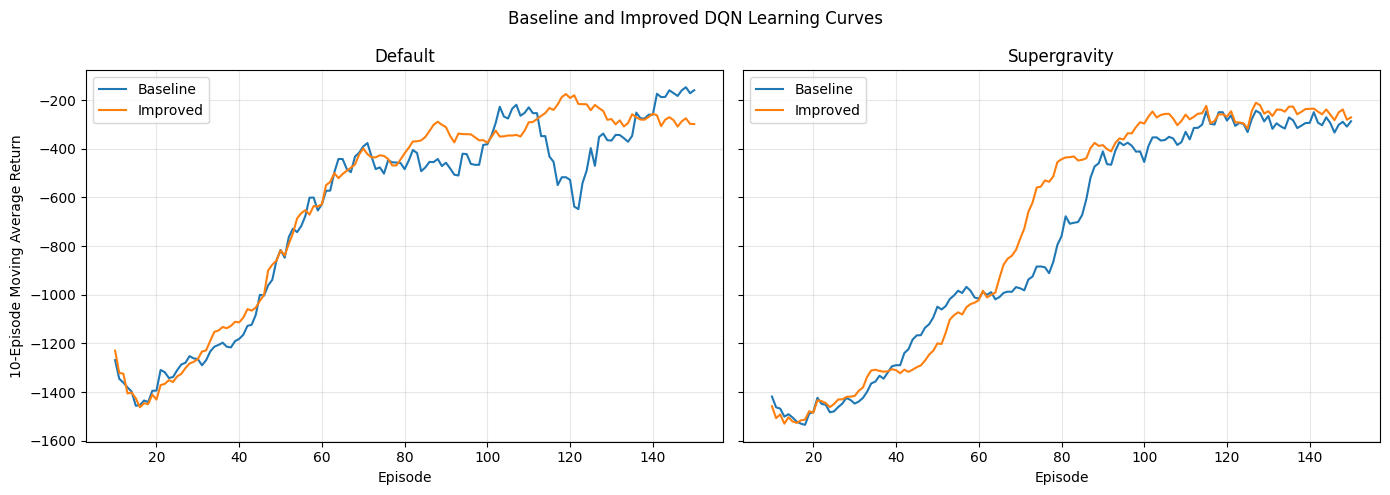

In [29]:
if baseline_results and improved_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for axis, gravity_name in zip(
        axes,
        ["Default", "Supergravity"]
    ):
        baseline_curve = moving_average(
            baseline_results[gravity_name]["returns"],
            window=10
        )
        improved_curve = moving_average(
            improved_results[gravity_name]["returns"],
            window=10
        )

        axis.plot(
            np.arange(10, 10 + len(baseline_curve)),
            baseline_curve,
            label="Baseline"
        )
        axis.plot(
            np.arange(10, 10 + len(improved_curve)),
            improved_curve,
            label="Improved"
        )

        axis.set_title(gravity_name)
        axis.set_xlabel("Episode")
        axis.grid(alpha=0.3)
        axis.legend()

    axes[0].set_ylabel("10-Episode Moving Average Return")
    plt.suptitle("Baseline and Improved DQN Learning Curves")
    plt.tight_layout()
    plt.show()
else:
    print("Train both baseline and Improved DQN agents first.")


## Final Greedy Evaluation

Training rewards include epsilon-greedy exploration and are therefore not sufficient for final model selection. All four trained agents are evaluated using the same 30 starting seeds with exploration disabled. No network updates or replay-buffer additions occur during evaluation.

Because Pendulum rewards are negative, a mean or median closer to zero indicates better performance. A smaller standard deviation and less-negative worst return indicate greater reliability.

In [30]:
def evaluate_agent(training_result, evaluation_seeds):
    agent = training_result["agent"]
    config = training_result["config"]
    action_values = training_result["action_values"]
    env = create_env(config["gravity"])

    evaluation_returns = []

    for seed in evaluation_seeds:
        state = reset_environment(env, seed=int(seed))
        done = False
        total_reward = 0.0

        while not done:
            action_index = agent.act(state, explore=False)
            torque = action_index_to_torque(action_index, action_values)
            state, reward, done, _ = step_environment(env, torque)
            total_reward += reward

        evaluation_returns.append(total_reward)

    env.close()
    return np.asarray(evaluation_returns, dtype=np.float32)


In [35]:
evaluation_seeds = np.arange(1000, 1030)
evaluation_results = {}
summary_rows = []

for gravity_name in ["Default", "Supergravity"]:
    for model_name, result_collection in [
        ("Baseline", baseline_results),
        ("Improved", improved_results)
    ]:
        returns = evaluate_agent(
            result_collection[gravity_name],
            evaluation_seeds
        )

        evaluation_results[
            (gravity_name, model_name)
        ] = returns

        summary_rows.append({
            "Gravity": gravity_name,
            "Model": model_name,
            "Mean": np.mean(returns),
            "Median": np.median(returns),
            "Std Dev": np.std(returns),
            "Best": np.max(returns),
            "Worst": np.min(returns)
        })


print(
    f"{'Gravity':<15}"
    f"{'Model':<12}"
    f"{'Mean':>12}"
    f"{'Median':>12}"
    f"{'Std Dev':>12}"
    f"{'Best':>12}"
    f"{'Worst':>12}"
)

print("-" * 87)

for row in summary_rows:
    print(
        f"{row['Gravity']:<15}"
        f"{row['Model']:<12}"
        f"{row['Mean']:>12.2f}"
        f"{row['Median']:>12.2f}"
        f"{row['Std Dev']:>12.2f}"
        f"{row['Best']:>12.2f}"
        f"{row['Worst']:>12.2f}"
    )

Gravity        Model               Mean      Median     Std Dev        Best       Worst
---------------------------------------------------------------------------------------
Default        Baseline         -159.80     -126.53       99.66       -1.46     -399.97
Default        Improved         -155.64     -131.54       83.55       -8.40     -353.84
Supergravity   Baseline         -264.28     -223.80      177.31       -0.88     -687.49
Supergravity   Improved         -214.36     -217.98      115.98       -1.66     -514.88


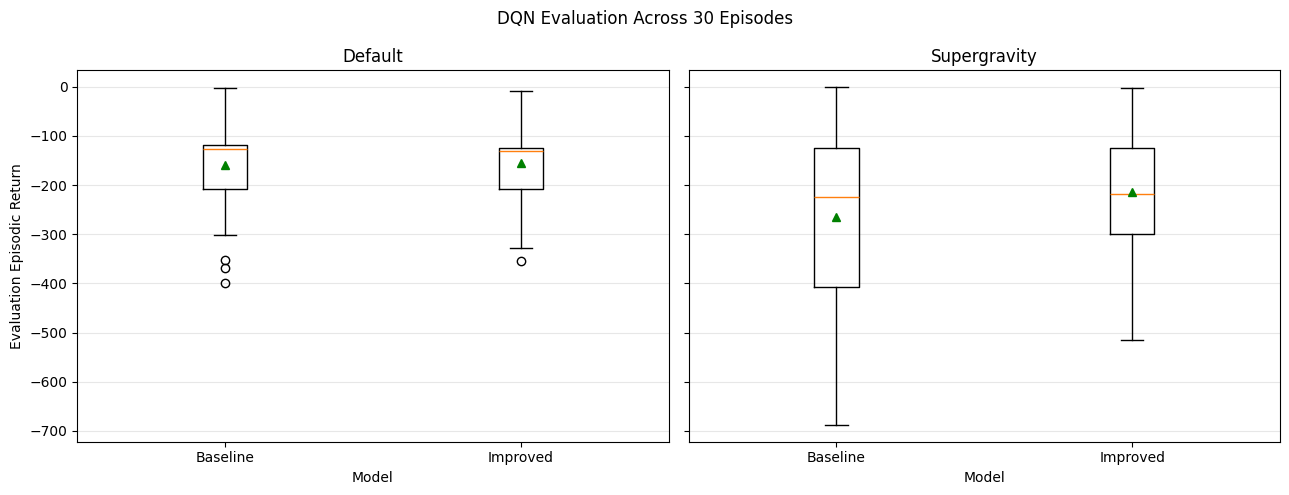

In [36]:
if evaluation_results:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 5),
        sharey=True
    )

    for axis, gravity_name in zip(
        axes,
        ["Default", "Supergravity"]
    ):
        values = [
            evaluation_results[(gravity_name, "Baseline")],
            evaluation_results[(gravity_name, "Improved")]
        ]

        axis.boxplot(
            values,
            tick_labels=["Baseline", "Improved"],
            showmeans=True,
            meanprops={
                "marker": "^",
                "markerfacecolor": "green",
                "markeredgecolor": "green"
            }
        )
        axis.set_title(gravity_name)
        axis.set_xlabel("Model")
        axis.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Evaluation Episodic Return")
    plt.suptitle("DQN Evaluation Across 30 Episodes")
    plt.tight_layout()
    plt.show()


## Final Model Selection

One DQN architecture must be selected for comparison with the other group members’ DQN agents. The code below selects the architecture with the higher average mean return across the two assigned gravity conditions. Stability, represented by standard deviation and worst-case performance, should also be discussed before confirming the final choice.

In [38]:
architecture_summary = {}

for model_name in ["Baseline", "Improved"]:
    model_rows = [
        row for row in summary_rows
        if row["Model"] == model_name
    ]

    architecture_summary[model_name] = {
        "Average Mean Return": np.mean([
            row["Mean"] for row in model_rows
        ]),
        "Average Std Dev": np.mean([
            row["Std Dev"] for row in model_rows
        ])
    }


print(
    f"{'Model':<15}"
    f"{'Average Mean Return':>22}"
    f"{'Average Std Dev':>20}"
)

print("-" * 57)

for model_name, values in architecture_summary.items():
    print(
        f"{model_name:<15}"
        f"{values['Average Mean Return']:>22.2f}"
        f"{values['Average Std Dev']:>20.2f}"
    )


# Select the architecture with the mean return closest to zero
selected_model = max(
    architecture_summary,
    key=lambda model: architecture_summary[
        model
    ]["Average Mean Return"]
)

# Find which gravity performed better for the selected model
selected_model_rows = [
    row for row in summary_rows
    if row["Model"] == selected_model
]

better_gravity_row = max(
    selected_model_rows,
    key=lambda row: row["Mean"]
)

better_gravity = better_gravity_row["Gravity"]

print("\nSelected DQN architecture:", selected_model)

print(
    f"The selected architecture performed better under "
    f"{better_gravity} gravity because its mean return "
    f"was closer to zero."
)

Model             Average Mean Return     Average Std Dev
---------------------------------------------------------
Baseline                      -212.04              138.48
Improved                      -185.00               99.76

Selected DQN architecture: Improved
The selected architecture performed better under Default gravity because its mean return was closer to zero.


## Final Model Selection

The **Improved DQN** was selected as the final architecture for comparison with the other group members’ agents.

Across Default and Supergravity, the Improved DQN achieved an average mean return of **−185.00**, compared with **−212.04** for the Baseline DQN. Since Pendulum returns are negative, a value closer to zero represents better performance.

The Improved DQN also achieved a lower average standard deviation of **99.76**, compared with **138.48** for the baseline. This indicates that it produced more consistent evaluation results and was less likely to experience extremely poor episodes.

The Improved DQN performed better under **Default gravity** than Supergravity because its mean return was closer to zero. The stronger downward force under Supergravity made balancing the pendulum more difficult.

Overall, the Improved DQN was selected because it provided both better average performance and greater stability across the two assigned gravity conditions.